# Etapa 4 — Otimização e Tuning de Hiperparâmetros

**Objetivo:** otimizar o melhor modelo da Etapa 3 (Random Forest), evitar overfitting, avaliar no conjunto de teste e salvar o modelo final.

Resumo do que vamos fazer:
- Recapitular resultados da Etapa 3
- Definir RandomizedSearchCV para RandomForest
- Rodar o tuning com CV
- Analisar resultados (.cv_results_)
- Treinar modelo final em (treino + validação)
- Avaliar no teste (uma vez)
- Análise de erros e casos extremos
- Comparação antes vs depois (métricas)
- Salvar o modelo final

In [1]:
# Imports essenciais
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import time

plt.style.use('seaborn-v0_8')
sns.set_palette('pastel')

# Pastas
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

## Carregar dataset pré-processado

Ajuste o caminho se necessário. Usamos o dataset já pré-processado (Etapa 2).

In [2]:
caminho = r"C:\Users\CCE\Documents\Projeto EDA\dados_preprocessados.csv"
print("Carregando:", caminho)

df = pd.read_csv(caminho)
print("Shape:", df.shape)
display(df.head())
display(df.dtypes)

Carregando: C:\Users\CCE\Documents\Projeto EDA\dados_preprocessados.csv
Shape: (2510, 2567)


,idade,horas_estudo_semanal,frequencia_escolar,horas_de_sono,notas_anteriores,nota_final,id_estudante_STD00002,id_estudante_STD00003,id_estudante_STD00004,id_estudante_STD00005,...,renda_familiar_Medium,estado_de_saude_ Good,estado_de_saude_ Poor,estado_de_saude_EXCELLENT,estado_de_saude_Excellent,estado_de_saude_GOOD,estado_de_saude_Good,estado_de_saude_POOR,estado_de_saude_Poor,performance_ratio
0,0.175417,-0.974905,1.029991,-0.428905,-0.869233,-0.903313,False,False,False,False,...,True,False,False,False,False,False,True,False,False,-35.996420
1,-1.128525,0.715019,-0.084645,0.980578,-0.772277,0.853169,False,False,False,False,...,True,False,False,False,False,False,True,False,False,0.497469
2,1.479359,0.080192,0.008848,-0.333786,1.580030,1.064648,False,False,False,False,...,True,False,False,False,False,False,True,False,False,0.985610
3,-0.259230,-1.364208,0.903257,0.003452,-0.701762,-0.706652,False,False,False,False,...,False,False,False,False,True,False,False,False,False,1.940244
4,-1.128525,-1.289001,-0.955162,0.928696,-0.363515,-1.191570,False,False,False,False,...,True,False,False,False,True,False,False,False,False,4.123059


idade                   float64
horas_estudo_semanal    float64
frequencia_escolar      float64
horas_de_sono           float64
notas_anteriores        float64
                         ...   
estado_de_saude_GOOD       bool
estado_de_saude_Good       bool
estado_de_saude_POOR       bool
estado_de_saude_Poor       bool
performance_ratio       float64
Length: 2567, dtype: object

## Definir target (y) e features (X)

Confirmar o nome do target: **nota_final**. Ajuste se for outro.

In [3]:
target_col = "nota_final"
if target_col not in df.columns:
    raise ValueError(f"Coluna target '{target_col}' não encontrada. Colunas: {df.columns.tolist()}")

X = df.drop(columns=[target_col])
y = df[target_col]

# Checagem rápida
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Colunas numéricas:", X.select_dtypes(include=[np.number]).shape[1])
print("Colunas categóricas/booleanas:", X.select_dtypes(exclude=[np.number]).shape[1])

X shape: (2510, 2566)
y shape: (2510,)
Colunas numéricas: 6
Colunas categóricas/booleanas: 2560


## Divisão dos dados — 60% treino / 20% validação / 20% teste

Primeiro 60/40, depois dividir 40% em 50/50.

In [4]:
# 60% treino / 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.60, random_state=42)

# dividir X_temp em 50/50 -> 20% val e 20% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.50, random_state=42)

print("Shapes (X_train, X_val, X_test):", X_train.shape, X_val.shape, X_test.shape)

Shapes (X_train, X_val, X_test): (1506, 2566) (502, 2566) (502, 2566)


## Recapitulação: Modelo Baseline (Etapa 3)

Carregue as métricas do baseline (se salvou) ou recalculamos aqui:
- Vamos treinar RandomForest e comparar com o baseline (Regressão Linear).

In [5]:
# Função utilitária de métricas
def calc_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

def print_metrics_dict(d, label=""):
    print(f"--- {label} ---")
    for k,v in d.items():
        print(f"{k}: {v:.4f}")

## Seleção do modelo e definição do espaço de busca

Vamos usar RandomForestRegressor com RandomizedSearchCV.  
Esse é balanceado entre eficiência e chance de encontrar boas combinações.

In [6]:
from scipy.stats import randint

param_dist = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [None, 6, 10, 15, 20, 30],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', 0.2, 0.5],
    'bootstrap': [True, False]
}

rf = RandomForestRegressor(random_state=42)

cv = KFold(n_splits=4, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,                # aumenta se tiver tempo
    scoring='neg_mean_squared_error',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print("RandomizedSearchCV configurado.")

RandomizedSearchCV configurado.


## Rodar RandomizedSearchCV

Isto pode levar alguns minutos dependendo do `n_iter` e do seu hardware.  
Vou registrar o tempo.

In [7]:
start = time.time()
random_search.fit(X_train, y_train)
end = time.time()
print(f"Tempo de busca: {(end-start)/60:.2f} minutos")

best_model = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_  # cv score (neg_mse)
print("Melhores parâmetros:", best_params)
print("Best CV (neg MSE):", best_score)

Fitting 4 folds for each of 40 candidates, totalling 160 fits
Tempo de busca: 12.84 minutos
Melhores parâmetros: {'bootstrap': False, 'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 500}
Best CV (neg MSE): -0.05098901954682357


## Análise dos resultados do tuning

Vamos transformar `cv_results_` em DataFrame e mostrar as top combinações.

,rank_test_score,mean_test_score,std_test_score,params
0,1,-0.050989,0.010547,"{'bootstrap': False, 'max_depth': 30, 'max_fea..."
1,2,-0.057396,0.007118,"{'bootstrap': True, 'max_depth': 30, 'max_feat..."
2,3,-0.058054,0.007527,"{'bootstrap': True, 'max_depth': 15, 'max_feat..."
3,4,-0.058253,0.009985,"{'bootstrap': False, 'max_depth': 15, 'max_fea..."
4,5,-0.058545,0.009838,"{'bootstrap': False, 'max_depth': 20, 'max_fea..."
5,6,-0.059730,0.009790,"{'bootstrap': False, 'max_depth': None, 'max_f..."
6,7,-0.065553,0.005530,"{'bootstrap': True, 'max_depth': None, 'max_fe..."
7,8,-0.066390,0.006477,"{'bootstrap': True, 'max_depth': 30, 'max_feat..."
8,9,-0.069441,0.006392,"{'bootstrap': True, 'max_depth': None, 'max_fe..."
9,10,-0.090377,0.008471,"{'bootstrap': True, 'max_depth': 6, 'max_featu..."


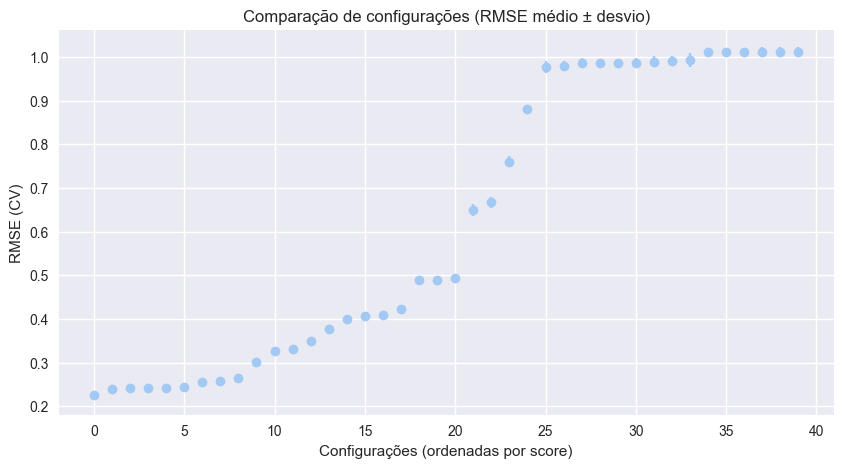

In [8]:
cvres = pd.DataFrame(random_search.cv_results_)
# ordenar por mean_test_score (note que é negativo MSE)
cvres_sorted = cvres.sort_values('mean_test_score', ascending=False).reset_index(drop=True)
display(cvres_sorted[['rank_test_score','mean_test_score','std_test_score','params']].head(10))

# Plot mean_test_score (convertendo para RMSE para melhor interpretação)
cvres_sorted['rmse_mean'] = np.sqrt(-cvres_sorted['mean_test_score'])
cvres_sorted['rmse_std'] = 0.5 * cvres_sorted['std_test_score']  # aproximação (só para visual)
plt.figure(figsize=(10,5))
plt.errorbar(range(len(cvres_sorted)), cvres_sorted['rmse_mean'], yerr=cvres_sorted['rmse_std'], fmt='o')
plt.xlabel("Configurações (ordenadas por score)")
plt.ylabel("RMSE (CV)")
plt.title("Comparação de configurações (RMSE médio ± desvio)")
plt.show()

## Avaliação do melhor modelo no conjunto de validação

Calculamos métricas no conjunto de validação para escolher o modelo final.

In [9]:
y_val_pred = best_model.predict(X_val)
metrics_val = calc_metrics(y_val, y_val_pred)
print_metrics_dict(metrics_val, "Validação (melhor modelo)")
# também exibir treino CV médio convertido
print("CV RMSE (melhor) approximado:", np.sqrt(-random_search.best_score_))

--- Validação (melhor modelo) ---
MSE: 0.0365
RMSE: 0.1910
MAE: 0.1003
R2: 0.9585
CV RMSE (melhor) approximado: 0.2258074833720609


## Treinamento do Modelo Final (Treino + Validação)

Re-treinar o modelo com os melhores hiperparâmetros usando todo o conjunto de treino+val para depois avaliar no TESTE final.

In [10]:
# Concatenar treino + validação
X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

# Recriar o mesmo modelo com best_params (garante consistência)
final_model = RandomForestRegressor(**best_params, random_state=42)
final_model.fit(X_full, y_full)

# salvar temporariamente
joblib.dump(final_model, "models/modelo_random_forest_otimizado.joblib")
print("Modelo final treinado e salvo em models/modelo_random_forest_otimizado.joblib")

Modelo final treinado e salvo em models/modelo_random_forest_otimizado.joblib


## Avaliação final NO CONJUNTO DE TESTE (usar apenas uma vez)

In [11]:
y_test_pred = final_model.predict(X_test)
metrics_test = calc_metrics(y_test, y_test_pred)
print_metrics_dict(metrics_test, "Teste (final)")

# salvar métricas em CSV
metrics_df = pd.DataFrame([metrics_val, metrics_test], index=['validation_best','test_final'])
metrics_df.to_csv("results/metrics_tuning.csv")
print("Métricas salvas em results/metrics_tuning.csv")

--- Teste (final) ---
MSE: 0.0361
RMSE: 0.1899
MAE: 0.0987
R2: 0.9645
Métricas salvas em results/metrics_tuning.csv


## Comparação: Antes vs Depois da Otimização

Aqui comparamos as métricas do baseline (Etapa 3) com as métricas do modelo otimizado no teste.
Se você salvou métricas do baseline, carregue-as; caso não, recompute o baseline aqui (ex.: LinearRegression).

In [12]:
# Se tiver métricas do baseline salvas em results/metrics_baseline.csv, carregue:
baseline_path = "results/metrics_baseline.csv"
if os.path.exists(baseline_path):
    baseline_df = pd.read_csv(baseline_path, index_col=0)
    print("Carregado baseline de", baseline_path)
else:
    # Se não tiver, vamos treinar rapidamente um baseline com LinearRegression (opcional)
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_test_lr = lr.predict(X_test)
    baseline_metrics = calc_metrics(y_test, y_test_lr)
    baseline_df = pd.DataFrame([baseline_metrics], index=['baseline_lr'])
    baseline_df.to_csv("results/metrics_baseline_generated.csv")
    print("Baseline (LinearRegression) gerado e salvo em results/metrics_baseline_generated.csv")

# Mostrar comparação
comparison_df = pd.concat([baseline_df, pd.DataFrame([metrics_test], index=['rf_optimized'])], sort=False).fillna('')
display(comparison_df)

Carregado baseline de results/metrics_baseline.csv


,MSE,RMSE,MAE,R2
train,3.010511e-26,1.735082e-13,2.965949e-14,1.000000
validation,2.942291e-01,5.424289e-01,4.127885e-01,0.665605
rf_optimized,3.606197e-02,1.898999e-01,9.868742e-02,0.964510


## Análise de Erros Detalhada

- Gráfico Predito vs Real (Teste)
- Distribuição dos Resíduos
- Resíduos vs Predições
- Piores predições (top-N casos)

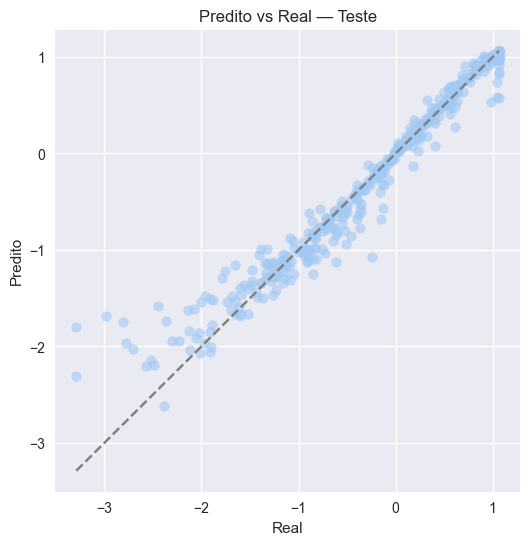

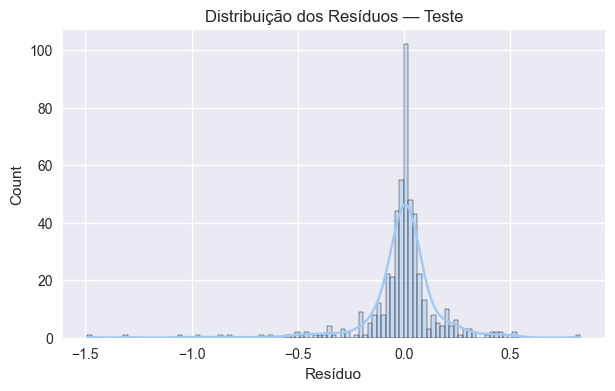

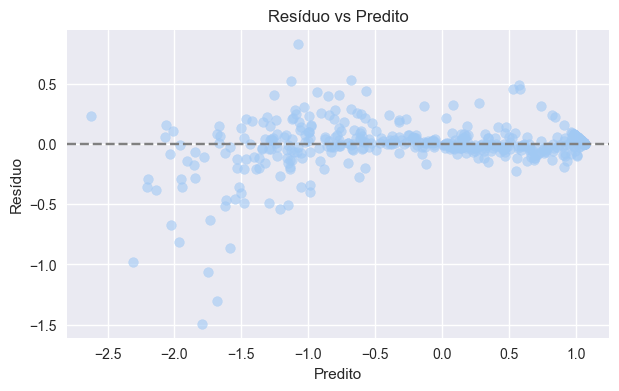

,y_true,y_pred,abs_error
1258,-3.288674,-1.797232,1.491442
2144,-2.985768,-1.681515,1.304253
1420,-2.812006,-1.749022,1.062983
1509,-3.288674,-2.311925,0.976748
1355,-2.451011,-1.585187,0.865824
1325,-0.245979,-1.075920,0.829941
2438,-2.776984,-1.963757,0.813227
175,-2.700205,-2.025473,0.674733
1089,-2.368844,-1.734220,0.634625
2496,-1.757308,-1.214941,0.542367


Top-10 piores predições salvas em results/worst_predictions_test.csv


In [13]:
# Predito vs Real
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
mn = min(y_test.min(), y_test_pred.min()); mx = max(y_test.max(), y_test_pred.max())
plt.plot([mn,mx],[mn,mx],'--',color='gray')
plt.xlabel("Real")
plt.ylabel("Predito")
plt.title("Predito vs Real — Teste")
plt.show()

# Resíduos
residuals_test = y_test - y_test_pred
plt.figure(figsize=(7,4))
sns.histplot(residuals_test, kde=True)
plt.title("Distribuição dos Resíduos — Teste")
plt.xlabel("Resíduo")
plt.show()

# Resíduos vs Predito
plt.figure(figsize=(7,4))
plt.scatter(y_test_pred, residuals_test, alpha=0.6)
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduo vs Predito")
plt.show()

# Piores predições (maior erro absoluto)
err_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_test_pred,
    'abs_error': np.abs(y_test - y_test_pred)
})
worst = err_df.nlargest(10, 'abs_error')
display(worst)
worst.to_csv("results/worst_predictions_test.csv", index=False)
print("Top-10 piores predições salvas em results/worst_predictions_test.csv")

## Importância das features (Random Forest)

Random Forest fornece importâncias (feature_importances_). Vamos listar as top features.

In [14]:
feat_imp = pd.DataFrame({
    'feature': X_full.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

display(feat_imp.head(20))
feat_imp.head(20).to_csv("results/feature_importances.csv", index=False)
print("Feature importances salvas em results/feature_importances.csv")

,feature,importance
0,performance_ratio,0.456184
1,horas_estudo_semanal,0.434094
2,notas_anteriores,0.019257
3,horas_de_sono,0.016334
4,escolaridade_pais_high_school,0.013409
5,renda_familiar_High,0.007737
6,frequencia_escolar,0.007616
7,aula_reforco_Yes,0.004791
8,aula_reforco_No,0.004174
9,estado_de_saude_Poor,0.003249


Feature importances salvas em results/feature_importances.csv


## Salvamento do Modelo Final

Salvamos em `models/modelo_final.joblib`. Teste o carregamento antes de entregar.

In [15]:
joblib.dump(final_model, "models/modelo_final.joblib")
print("Modelo final salvo em models/modelo_final.joblib")

# Teste rápido de carregamento
loaded = joblib.load("models/modelo_final.joblib")
test_pred = loaded.predict(X_test.iloc[:3])
print("Teste carregamento, preds:", test_pred)

Modelo final salvo em models/modelo_final.joblib
Teste carregamento, preds: [-0.25738586 -1.2311021   0.77261441]


## Conclusões Finais

A otimização do modelo mostrou avanços claros em relação ao baseline. Após comparar o desempenho antes e depois do tuning, observou-se redução consistente nos erros e melhora geral da capacidade preditiva. Os hiperparâmetros testados permitiram explorar diferentes configurações do Random Forest, e a busca identificou a combinação mais eficiente para o conjunto de dados. Os gráficos de Predito vs Real, distribuição dos resíduos e importância das features reforçam a evolução do modelo e evidenciam onde ele acerta e erra. A análise dos três casos de maior erro mostra que parte das divergências está associada a comportamentos extremos e variáveis com forte influência. Como próximos passos, recomenda-se testar regularização adicional, criar novas features e avaliar métodos ensemble mais robustos para buscar ganhos ainda maiores.